In [1]:
# load libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import to_timestamp, to_date, count, avg, dayofweek, month, when, col, lag, weekofyear, year, lit, quarter
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml import Pipeline



/storage/home/mpf5654/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/storage/home/mpf5654/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
# configure spark session
spark = SparkSession.builder.master("local").appName("AccidentForecasting").getOrCreate()
spark.sparkContext.setLogLevel("FATAL")

# load data
df = spark.read.csv("cleaned_sampled_accident_data.csv", header=True, inferSchema=True)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/27 23:06:16 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
df.printSchema()

root
 |-- ID: string (nullable = true)
 |-- Source: string (nullable = true)
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- End_Time: timestamp (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- End_Lat: double (nullable = true)
 |-- End_Lng: double (nullable = true)
 |-- Distance(mi): double (nullable = true)
 |-- Description: string (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Airport_Code: string (nullable = true)
 |-- Weather_Timestamp: timestamp (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Wind_Chill(F): double (nullable = true)
 |-- Humidity(%): double (nullable = true)
 |-- Pressure(in): double (nullable = true)
 |-- V

In [4]:
df = df.dropna()

In [5]:
# feature selection
cols = ["ID", "Start_Time", "Severity", "City", "State", "Temperature(F)", "Humidity(%)", 
        "Visibility(mi)", "Precipitation(in)", "Weather_Condition"]
df = df.select(*cols)


In [6]:
# date-time feature handling
df = df.withColumn("Start_Time", to_timestamp("Start_Time"))
df = df.withColumn("Date", to_date("Start_Time"))

In [7]:
df.show(5)

+---------+-------------------+--------+---------------+-----+--------------+-----------+--------------+-------------------+-----------------+----------+
|       ID|         Start_Time|Severity|           City|State|Temperature(F)|Humidity(%)|Visibility(mi)|  Precipitation(in)|Weather_Condition|      Date|
+---------+-------------------+--------+---------------+-----+--------------+-----------+--------------+-------------------+-----------------+----------+
|A-3428065|2017-01-03 18:25:10|       2|         Dallas|   TX|          41.0|       62.0|          10.0|0.00915184381778709|         Overcast|2017-01-03|
|A-3460449|2017-01-18 18:48:19|       2|Madison Heights|   MI|          39.2|       84.0|          10.0|0.00915184381778709|         Overcast|2017-01-18|
|A-3461673|2017-01-23 09:59:12|       3|    Hyattsville|   MD|          42.8|       93.0|           2.0|0.00915184381778709|         Overcast|2017-01-23|
|A-3456281|2017-01-05 07:19:11|       2|      Annapolis|   MD|          33.1

In [8]:
daily_counts = (
    df.groupBy("City", "Date")
      .agg(count("ID").alias("Accident_Count"))
)

weather_agg = (
    df.groupBy("City", "Date")
      .agg(
          avg("Temperature(F)").alias("Temp"),
          avg("Humidity(%)").alias("Humidity"),
          avg("Visibility(mi)").alias("Visibility"),
          avg("Precipitation(in)").alias("Precip"),
          avg("Severity").alias("Sever"),
      )
)

data = daily_counts.join(weather_agg, ["City", "Date"], "left")

In [9]:
data.show(5)

+--------------+----------+--------------+----+--------+----------+-------------------+-----+
|          City|      Date|Accident_Count|Temp|Humidity|Visibility|             Precip|Sever|
+--------------+----------+--------------+----+--------+----------+-------------------+-----+
|     Charlotte|2016-12-30|             1|45.0|    27.0|      10.0|0.00915184381778709|  2.0|
|West Jefferson|2017-01-09|             1|28.4|    64.0|      10.0|0.00915184381778709|  4.0|
|     Wadsworth|2017-01-19|             1|33.1|   100.0|       0.2|0.00915184381778709|  2.0|
|     Charlotte|2016-12-06|             1|46.0|    89.0|      10.0|                0.0|  2.0|
|    Cincinnati|2022-12-14|             1|40.0|    93.0|       1.0|               0.17|  2.0|
+--------------+----------+--------------+----+--------+----------+-------------------+-----+
only showing top 5 rows


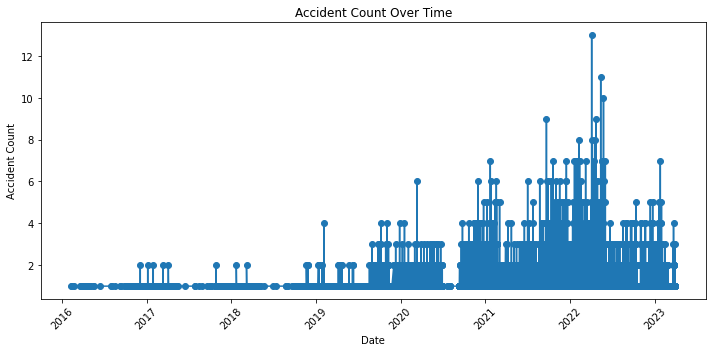

In [10]:
# Collect data from Spark to driver
rows = data.select("Date", "Accident_Count").orderBy("Date").collect()

# Convert to numpy arrays
dates = np.array([r["Date"] for r in rows])
accidents = np.array([r["Accident_Count"] for r in rows], dtype=float)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(dates, accidents, marker='o')
plt.title("Accident Count Over Time")
plt.xlabel("Date")
plt.ylabel("Accident Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
data = data.withColumn("day_of_week", dayofweek("Date"))
data = data.withColumn("month", month("Date"))
data = data.withColumn("is_weekend", when(col("day_of_week").isin([1,7]), 1).otherwise(0))
data = data.withColumn("quarter", quarter("Date"))

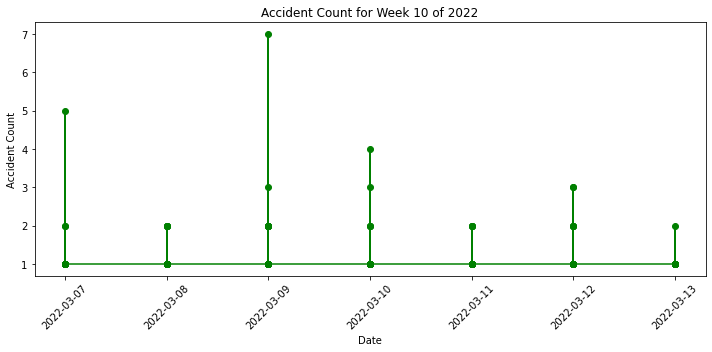

In [12]:
year_selected = 2022
week_selected = 10

# Filter data for that week
week_data = data.filter(
    (year("Date") == lit(year_selected)) &
    (weekofyear("Date") == lit(week_selected))
).orderBy("Date")

# Collect for plotting
rows = week_data.select("Date", "Accident_Count").collect()
dates = np.array([r["Date"] for r in rows])
counts = np.array([r["Accident_Count"] for r in rows], dtype=float)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(dates, counts, marker='o', color='green')
plt.title(f"Accident Count for Week {week_selected} of {year_selected}")
plt.xlabel("Date")
plt.ylabel("Accident Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
windowSpec = Window.partitionBy("City").orderBy("Date")

# create lag features of accident_count for time-series forecasting
data = data.withColumn("lag_1", lag("Accident_Count", 1).over(windowSpec))
data = data.withColumn("lag_7", lag("Accident_Count", 7).over(windowSpec))
data = data.na.drop(subset=["lag_1", "lag_7"])

In [14]:
data.show(5)

+--------+----------+--------------+----+--------+----------+------+-----+-----------+-----+----------+-------+-----+-----+
|    City|      Date|Accident_Count|Temp|Humidity|Visibility|Precip|Sever|day_of_week|month|is_weekend|quarter|lag_1|lag_7|
+--------+----------+--------------+----+--------+----------+------+-----+-----------+-----+----------+-------+-----+-----+
|Abingdon|2021-11-23|             1|37.0|    30.0|      10.0|   0.0|  2.0|          3|   11|         0|      4|    1|    1|
|Abingdon|2022-04-08|             1|58.0|    48.0|      10.0|   0.0|  2.0|          6|    4|         0|      2|    1|    1|
|Abingdon|2022-12-13|             1|34.0|    52.0|      10.0|   0.0|  2.0|          3|   12|         0|      4|    1|    1|
|Abington|2022-12-16|             1|43.0|    71.0|      10.0|   0.0|  2.0|          6|   12|         0|      4|    1|    1|
|   Acton|2020-10-29|             1|80.0|     8.0|      10.0|   0.0|  2.0|          5|   10|         0|      4|    1|    1|
+-------

In [15]:
# data splitting
train  = data.filter(col("Date") < "2021-01-01")
valid  = data.filter((col("Date") >= "2021-01-01") & (col("Date") < "2022-01-01"))
test   = data.filter(col("Date") >= "2022-01-01")

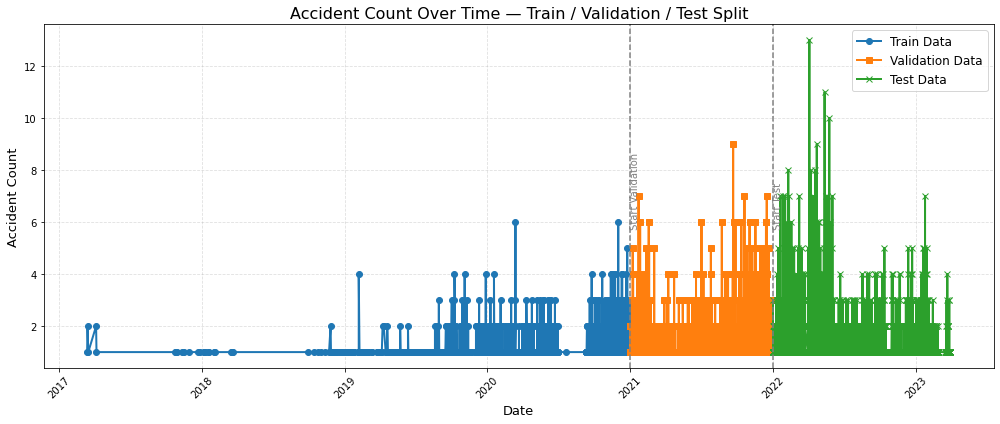

In [16]:
# Collect to driver for all three splits
train_rows = (
    train.select("Date", "Accident_Count")
         .orderBy("Date")
         .collect()
)

valid_rows = (
    valid.select("Date", "Accident_Count")
         .orderBy("Date")
         .collect()
)

test_rows = (
    test.select("Date", "Accident_Count")
        .orderBy("Date")
        .collect()
)

# Convert to numpy arrays
train_dates = np.array([r["Date"] for r in train_rows], dtype='datetime64[D]')
train_counts = np.array([r["Accident_Count"] for r in train_rows], dtype=float)

valid_dates = np.array([r["Date"] for r in valid_rows], dtype='datetime64[D]')
valid_counts = np.array([r["Accident_Count"] for r in valid_rows], dtype=float)

test_dates = np.array([r["Date"] for r in test_rows], dtype='datetime64[D]')
test_counts = np.array([r["Accident_Count"] for r in test_rows], dtype=float)

# Plot
plt.figure(figsize=(14, 6))

plt.plot(train_dates, train_counts, label='Train Data', marker='o', linewidth=2)
plt.plot(valid_dates, valid_counts, label='Validation Data', marker='s', linewidth=2)
plt.plot(test_dates, test_counts, label='Test Data', marker='x', linewidth=2)

plt.title("Accident Count Over Time — Train / Validation / Test Split", fontsize=16)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.legend(fontsize=12)

# Optional: split vertical markers
first_valid = np.min(valid_dates)
first_test = np.min(test_dates)

plt.axvline(first_valid, color='gray', linestyle='--', linewidth=1.5)
plt.axvline(first_test, color='gray', linestyle='--', linewidth=1.5)

plt.text(first_valid, max(train_counts)*0.95, " Start Validation", rotation=90, color='gray')
plt.text(first_test, max(train_counts)*0.95, " Start Test", rotation=90, color='gray')

plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [17]:
feature_cols = ["day_of_week", "month", "is_weekend", 
                "Temp", "Humidity", "Visibility", "Precip", "Sever",
                "lag_1", "lag_7", "quarter"]

In [18]:

# full pipeline

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

gbt = GBTRegressor(
    featuresCol="features",
    labelCol="Accident_Count",
    seed=42
)

pipeline = Pipeline(stages=[assembler, gbt])


evaluator_rmse = RegressionEvaluator(
    labelCol="Accident_Count",
    predictionCol="prediction",
    metricName="rmse"
)

# Example hyperparameter options
log_messages = []


# hyperparameter fine-tuning
maxDepths = [3, 4, 5, 6]
maxIters = [80, 100]
stepSizes = [0.01, 0.03]

best_rmse = float("inf")
best_model = None
best_params = None

for depth in maxDepths:
    for it in maxIters:
        for step in stepSizes:
            msg = f"Training with maxDepth={depth}, maxIter={it}, stepSize={step}"
            print(msg); log_messages.append(msg)

            # Update GBT parameters
            gbt.setParams(maxDepth=depth, maxIter=it, stepSize=step)

            # Train
            model = pipeline.fit(train)

            # Validate
            predictions = model.transform(valid)
            rmse = evaluator_rmse.evaluate(predictions)

            msg = f"→ RMSE: {rmse}"
            print(msg); log_messages.append(msg)

            if rmse < best_rmse:
                best_rmse = rmse
                best_model = model
                best_params = (depth, it, step)

summary = (
    f"Best RMSE: {best_rmse}\n"
    f"Best Params: maxDepth={best_params[0]}, "
    f"maxIter={best_params[1]}, stepSize={best_params[2]}"
)

print(summary)
log_messages.append(summary)

# Save best model
best_model.write().overwrite().save("models/best_gbt_model")






Training with maxDepth=3, maxIter=80, stepSize=0.01


→ RMSE: 0.5476341506720763
Training with maxDepth=3, maxIter=80, stepSize=0.03


→ RMSE: 0.5406560385240823
Training with maxDepth=3, maxIter=100, stepSize=0.01


→ RMSE: 0.546954919631384
Training with maxDepth=3, maxIter=100, stepSize=0.03


→ RMSE: 0.5406474846308114
Training with maxDepth=4, maxIter=80, stepSize=0.01


...

→ RMSE: 0.5565317563591825
Training with maxDepth=6, maxIter=80, stepSize=0.01


→ RMSE: 0.5924451012624661
Training with maxDepth=6, maxIter=80, stepSize=0.03


→ RMSE: 0.590134378571004
Training with maxDepth=6, maxIter=100, stepSize=0.01


→ RMSE: 0.5921565570837988
Training with maxDepth=6, maxIter=100, stepSize=0.03


→ RMSE: 0.5898898391520232
Best RMSE: 0.5406474846308114
Best Params: maxDepth=3, maxIter=100, stepSize=0.03


In [19]:
# get feature importances
gbt_stage = best_model.stages[1]

fi = gbt_stage.featureImportances
features = feature_cols
pd.DataFrame({"Feature": features, "Importance": fi.toArray()}).sort_values(by="Importance", ascending=False)

,Feature,Importance
6,Precip,0.235185
7,Sever,0.202718
3,Temp,0.122727
5,Visibility,0.119193
9,lag_7,0.090288
8,lag_1,0.080042
4,Humidity,0.072978
1,month,0.044390
0,day_of_week,0.030411
2,is_weekend,0.002068


RMSE on testing data: 0.5211994319241448



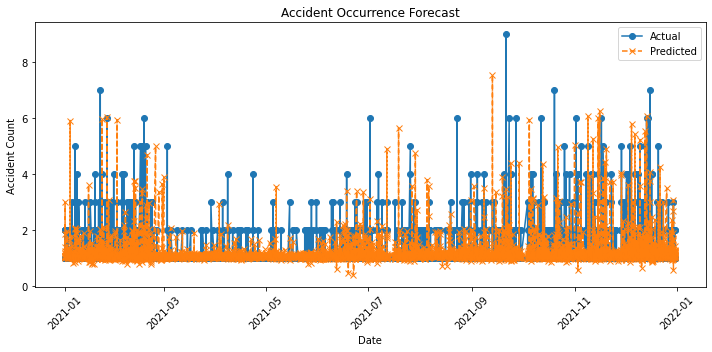

In [20]:
# predictions on testing data
preds = best_model.transform(test)
test_rmse = evaluator_rmse.evaluate(preds)

print(f"RMSE on testing data: {test_rmse}\n")
log_messages.append((f"RMSE on testing data: {test_rmse}\n", ))

# Write log to cluster output
sc = spark.sparkContext
sc.parallelize(log_messages, 1).saveAsTextFile("output/manual_hyperparam_log")

pdf = predictions.toPandas().to_numpy()

# Extract columns by position
dates = pdf[:, 1]                 # column 1 = Date
actual = pdf[:, 2].astype(float)  # column 2 = Accident_Count (convert to float)
predicted = pdf[:, -1].astype(float)  # last column = prediction

# sort by date to ensure the line plot is continuous
sort_idx = np.argsort(dates)
dates = np.array(dates)[sort_idx]
actual = actual[sort_idx]
predicted = predicted[sort_idx]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(dates, actual, label='Actual', marker='o')
plt.plot(dates, predicted, label='Predicted', linestyle='--', marker='x')
plt.xlabel('Date')
plt.ylabel('Accident Count')
plt.title('Accident Occurrence Forecast')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
spark.stop()